In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pybamm

In [2]:
sns.set_theme(style="whitegrid", palette="muted")

# Extract the actual thickness parameters directly from the PyBaMM model used during generation
# We load Chen2020 because we used its macro-geometry for our Virtual Cell Design
param_virtual = pybamm.ParameterValues("Chen2020") 
# Convert meters to micrometers
L_n = param_virtual["Negative electrode thickness [m]"] * 1e6
L_s = param_virtual["Separator thickness [m]"] * 1e6
L_p = param_virtual["Positive electrode thickness [m]"] * 1e6
L_total = L_n + L_s + L_p
# Calculate the precise Y-coordinates where the materials meet
sep_start = L_n
cat_start = L_n + L_s

print(f"Extracted Geometry: Anode={L_n:.1f}um, Separator={L_s:.1f}um, Cathode={L_p:.1f}um. Total={L_total:.1f}um")


dataset = np.load('dataset_lithium.npz')

X = dataset['X']
Y = dataset['Y']
T_durations = dataset['T']

num_samples = X.shape[0]
currents = X[:, 0]
D_anode = X[:, 1]         # absolute diffusivity [m2/s] -- unchanged semantics
D_cathode = X[:, 2]       # absolute diffusivity [m2/s] -- unchanged semantics
k_electrolyte = X[:, 3]   # scale factor (dimensionless, ~0.3x-3x) applied to the Nyman2008 curve

Extracted Geometry: Anode=85.2um, Separator=12.0um, Cathode=75.6um. Total=172.8um


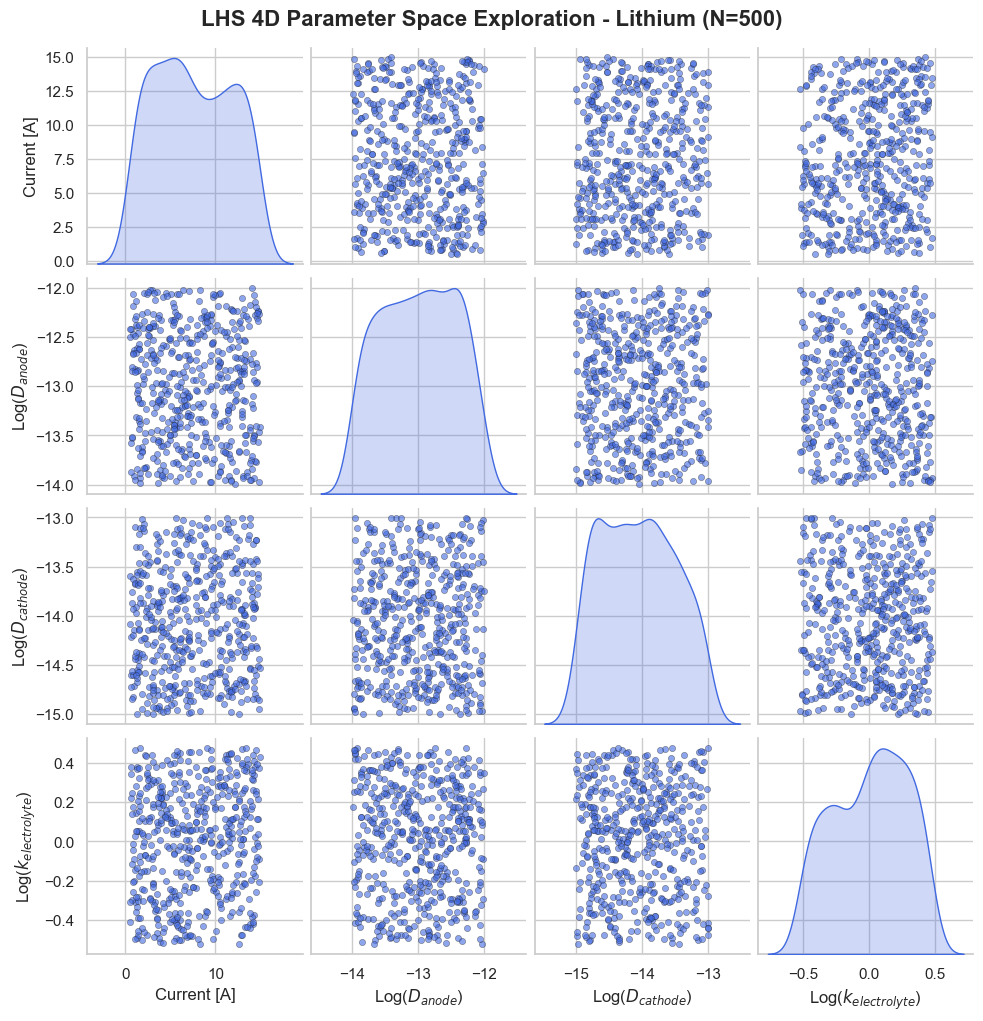

In [3]:
# PLOT 1: 4D PARAMETER SPACE (PAIRPLOT)
df_params = pd.DataFrame({
    'Current [A]': currents,
    'Log($D_{anode}$)': np.log10(D_anode),
    'Log($D_{cathode}$)': np.log10(D_cathode),
    'Log($k_{electrolyte}$)': np.log10(k_electrolyte),   # dimensionless scale factor now, not D
})
pairplot = sns.pairplot(
    df_params,
    diag_kind="kde",
    plot_kws={'alpha': 0.6, 's': 20, 'edgecolor': 'k', 'color': 'royalblue'},
    diag_kws={'color': 'royalblue'}
)
pairplot.figure.suptitle(f"LHS 4D Parameter Space Exploration - Lithium (N={num_samples})", y=1.02, fontsize=16, fontweight='bold')
plt.show()

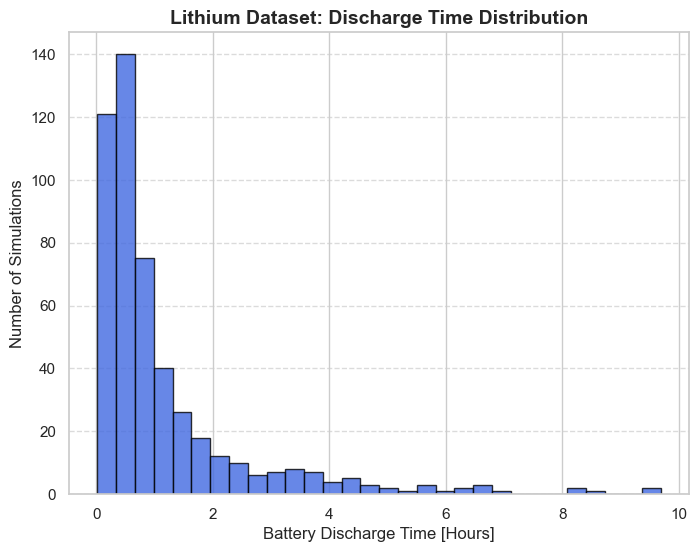

In [4]:
# PLOT 2: STATISTICAL ANALYSIS (DISCHARGE TIME HISTOGRAM)
fig2, ax2 = plt.subplots(figsize=(8, 6))
T_hours = T_durations / 3600.0  # Convert seconds to hours
ax2.hist(T_hours, bins=30, color='royalblue', edgecolor='black', alpha=0.8)
ax2.set_title('Lithium Dataset: Discharge Time Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Battery Discharge Time [Hours]', fontsize=12)
ax2.set_ylabel('Number of Simulations', fontsize=12)
ax2.grid(True, axis='y', ls="--", alpha=0.7)
plt.show()

<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\m'
C:\Users\angel\AppData\Local\Temp\ipykernel_13792\3685849902.py:55: SyntaxWarning: invalid escape sequence '\m'
  ax_heat[i].set_ylabel('Physical Depth [$\mu m$]', fontsize=12, fontweight='bold')


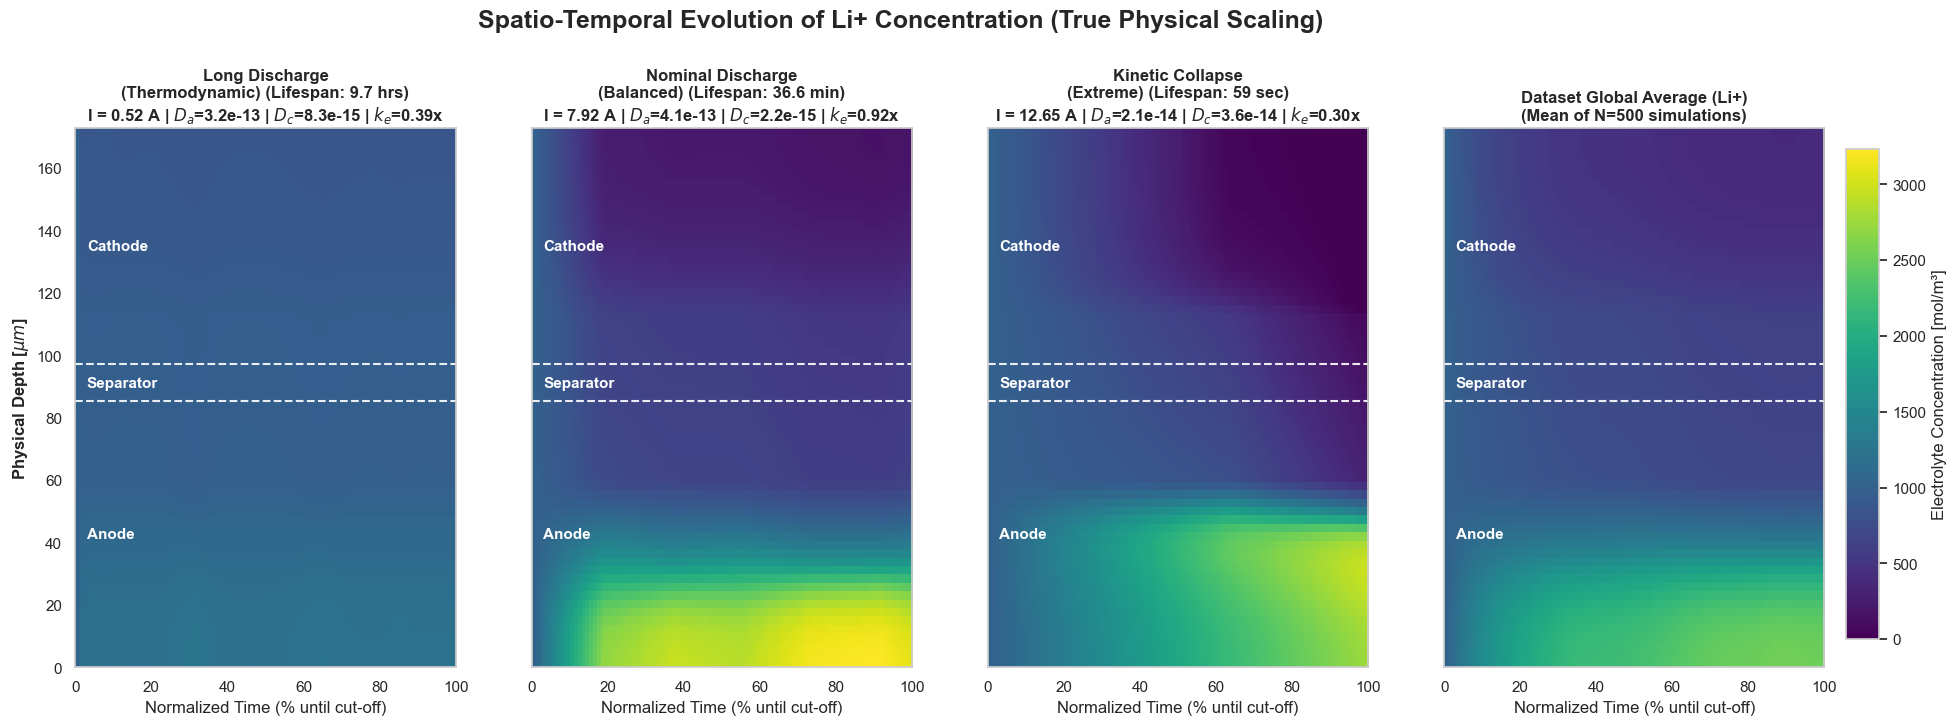

In [5]:
# PLOT 3: SPATIO-TEMPORAL HEATMAPS OF ELECTROLYTE CONCENTRATION
# Identify three representative scenarios based on their discharge time
idx_long = np.argmax(T_hours)
target_time = np.median(T_hours)
idx_mid = np.argmin(np.abs(T_hours - target_time))
idx_short = np.argmin(T_hours)
indices_to_show = [idx_long, idx_mid, idx_short]
titles = ['Long Discharge\n(Thermodynamic)', 'Nominal Discharge\n(Balanced)', 'Kinetic Collapse\n(Extreme)']

# Calculate the Global Average Heatmap across the dataset
Y_global_mean = np.mean(Y, axis=0)

fig3, ax_heat = plt.subplots(1, 4, figsize=(22, 7))

# Global vmin and vmax for consistent color scaling
vmin = min(np.min(Y[indices_to_show]), np.min(Y_global_mean))
vmax = max(np.max(Y[indices_to_show]), np.max(Y_global_mean))

for i, idx in enumerate(indices_to_show):
    data = Y[idx]

    val_I = X[idx, 0]
    val_Da = X[idx, 1]
    val_Dc = X[idx, 2]
    val_ke = X[idx, 3]   # scale factor, not absolute D -- formatted as a multiplier below
    time_h = T_hours[idx]

    if time_h < 0.017:  # under 1 minute
        duration_str = f"{time_h*3600:.0f} sec"
    elif time_h < 1:
        duration_str = f"{time_h*60:.1f} min"
    else:
        duration_str = f"{time_h:.1f} hrs"

    fullTitle = (
        f"{titles[i]} (Lifespan: {duration_str})\n"
        f"I = {val_I:.2f} A | $D_a$={val_Da:.1e} | $D_c$={val_Dc:.1e} | $k_e$={val_ke:.2f}x"
    )

    im = ax_heat[i].imshow(data, aspect='auto', origin='lower', cmap='viridis',
                           extent=[0, 100, 0, L_total], vmin=vmin, vmax=vmax)

    ax_heat[i].set_title(fullTitle, fontweight='bold', fontsize=12)

    # Draw boundaries
    ax_heat[i].axhline(y=sep_start, color='white', linestyle='--', linewidth=1.5, alpha=0.9)
    ax_heat[i].axhline(y=cat_start, color='white', linestyle='--', linewidth=1.5, alpha=0.9)
    ax_heat[i].text(3, L_n/2, 'Anode', color='white', va='center', fontweight='bold', fontsize=11)
    ax_heat[i].text(3, L_n + L_s/2, 'Separator', color='white', va='center', fontweight='bold', fontsize=11)
    ax_heat[i].text(3, L_n + L_s + L_p/2, 'Cathode', color='white', va='center', fontweight='bold', fontsize=11)
    ax_heat[i].grid(False)
    ax_heat[i].set_xlabel('Normalized Time (% until cut-off)', fontsize=12)

    if i == 0:
        ax_heat[i].set_ylabel('Physical Depth [$\mu m$]', fontsize=12, fontweight='bold')
    else:
        ax_heat[i].set_yticklabels([])

# 4th - Global Average Heatmap
im_mean = ax_heat[3].imshow(Y_global_mean, aspect='auto', origin='lower', cmap='viridis',
                            extent=[0, 100, 0, L_total], vmin=vmin, vmax=vmax)
ax_heat[3].set_title(f"Dataset Global Average (Li+)\n(Mean of N={num_samples} simulations)", fontweight='bold', fontsize=12)
ax_heat[3].axhline(y=sep_start, color='white', linestyle='--', linewidth=1.5, alpha=0.9)
ax_heat[3].axhline(y=cat_start, color='white', linestyle='--', linewidth=1.5, alpha=0.9)
ax_heat[3].text(3, L_n/2, 'Anode', color='white', va='center', fontweight='bold', fontsize=11)
ax_heat[3].text(3, L_n + L_s/2, 'Separator', color='white', va='center', fontweight='bold', fontsize=11)
ax_heat[3].text(3, L_n + L_s + L_p/2, 'Cathode', color='white', va='center', fontweight='bold', fontsize=11)
ax_heat[3].grid(False)
ax_heat[3].set_xlabel('Normalized Time (% until cut-off)', fontsize=12)
ax_heat[3].set_yticklabels([])

# Colorbar
fig3.subplots_adjust(right=0.92)
cbar_ax = fig3.add_axes([0.93, 0.15, 0.015, 0.7])
cbar = fig3.colorbar(im, cax=cbar_ax)
cbar.set_label('Electrolyte Concentration [mol/m\u00b3]', fontsize=12)

plt.suptitle('Spatio-Temporal Evolution of Li+ Concentration (True Physical Scaling)',
             fontsize=18, fontweight='bold', y=1.05)

plt.show()